## Project 2

Usage: Press "Run All"

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score
import pandas as pd








# TASK 1

## Data work

(13067, 400)
(13067,)


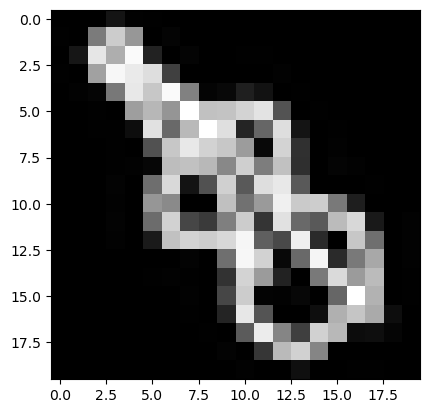

In [ ]:
seed = 16 

dataset = np.load("dataset.npz")
X, y = dataset["X"], dataset["y"]

print(X.shape)
print(y.shape)

plt.imshow(X[0].reshape(20,20), vmin=0, vmax=255, cmap="gray")
plt.show()





Examining the data 

Klasse 0: 546 observasjoner (4.18%)
Klasse 1: 900 observasjoner (6.89%)
Klasse 2: 804 observasjoner (6.15%)
Klasse 3: 454 observasjoner (3.47%)
Klasse 4: 1022 observasjoner (7.82%)
Klasse 5: 1362 observasjoner (10.42%)
Klasse 6: 858 observasjoner (6.57%)
Klasse 7: 557 observasjoner (4.26%)
Klasse 8: 888 observasjoner (6.80%)
Klasse 9: 834 observasjoner (6.38%)
Klasse 10: 782 observasjoner (5.98%)
Klasse 11: 1601 observasjoner (12.25%)
Klasse 12: 702 observasjoner (5.37%)
Klasse 13: 884 observasjoner (6.77%)
Klasse 14: 873 observasjoner (6.68%)


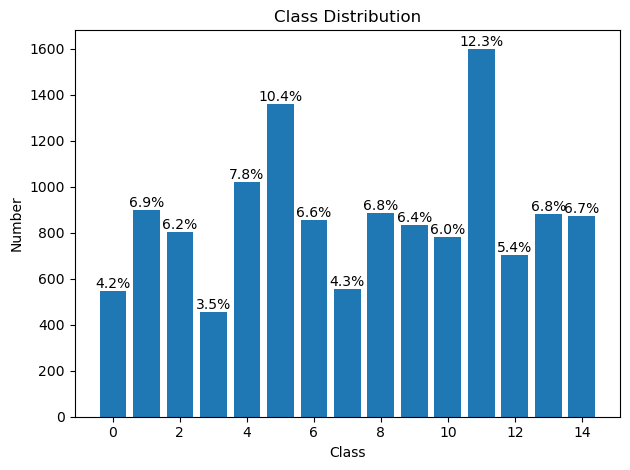

In [30]:
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Klasse {label}: {count} observasjoner ({count/len(y):.2%})")



classes, counts = np.unique(y, return_counts=True)
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number")
plt.title("Class Distribution")
plt.tight_layout()

total = len(y)
for c, n in zip(classes, counts):
    plt.text(c, n, f"{n/total:.1%}", ha="center", va="bottom")

Splitting into train and test set

In [ ]:

X_train_SVM, X_test_SVM, y_train_SVM, y_test_SVM = train_test_split(X, y, test_size=0.30, random_state=seed, stratify=y) 

print(X_train_SVM.shape)
print(y_train_SVM.shape)
print(X_test_SVM.shape)
print(y_test_SVM.shape)

(9146, 400)
(9146,)
(3921, 400)
(3921,)


## Classifier nr 1: Support Vector Machines

checking if data is seperatable by a linear function or not

In [32]:
pipe_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", tol=1e-3, max_iter=10000, random_state=seed)),
])

pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", class_weight="balanced",
                probability=False, cache_size=1000, tol=1e-3, max_iter=10000,
                random_state=seed)),
])

grid_lin = {"clf__C": [0.1, 1, 10]}
grid_rbf = {
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", 1e-3, 1e-2],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

gs_lin = GridSearchCV(pipe_lin, grid_lin, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True, verbose=0)
gs_rbf = GridSearchCV(pipe_rbf, grid_rbf, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True, verbose=0)

gs_lin.fit(X_train_SVM, y_train_SVM)
gs_rbf.fit(X_train_SVM, y_train_SVM)





,estimator,Pipeline(step...m_state=16))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__gamma': ['scale', 0.001, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [33]:


best_lin_score = gs_lin.best_score_
best_rbf_score = gs_rbf.best_score_
best_lin_params = gs_lin.best_params_
best_rbf_params = gs_rbf.best_params_


results = pd.DataFrame([
    ["SVM", "Linear", best_lin_params, round(best_lin_score, 3)],
    ["SVM", "RBF", best_rbf_params, round(best_rbf_score, 3)]
],
    columns=["Model", "Kernel", "Best Hyperparameters", "Best Macro-F1 (CV)"]
)

display(results) 

,Model,Kernel,Best Hyperparameters,Best Macro-F1 (CV)
0,SVM,Linear,{'clf__C': 0.1},0.604
1,SVM,RBF,"{'clf__C': 10, 'clf__gamma': 'scale'}",0.759




- RFB is preffered.

In [34]:


pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", class_weight="balanced",
                probability=False, cache_size=1000,
                tol=1e-2, max_iter=10000, random_state=seed))
])


param_grid_rbf = {
    "clf__C": [5,10,15,20,25,30,35],
    "clf__gamma": [1e-3, 3e-3, 1e-2, 3e-2, "scale"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

gs_rbf_refined = GridSearchCV(
    pipe_rbf,
    param_grid=param_grid_rbf,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

gs_rbf_refined.fit(X_train_SVM, y_train_SVM)

print("Best parameters:", gs_rbf_refined.best_params_)
print("Best CV macro-F1:", gs_rbf_refined.best_score_)

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best parameters: {'clf__C': 5, 'clf__gamma': 'scale'}
Best CV macro-F1: 0.7707931566898225


### Fitting final SVM

In [36]:
from sklearn.metrics import confusion_matrix


best_rbf_final = gs_rbf_refined.best_estimator_.fit(X_train_SVM, y_train_SVM)

y_pred_SVM = best_rbf_final.predict(X_test_SVM)
print("Test Macro-F1:", f1_score(y_test_SVM, y_pred_SVM, average="macro"))
print(classification_report(y_test_SVM, y_pred_SVM, digits=3))


Test Macro-F1: 0.7704261619520157
              precision    recall  f1-score   support

           0      0.814     0.774     0.794       164
           1      0.607     0.715     0.656       270
           2      0.910     0.842     0.875       241
           3      0.615     0.493     0.547       136
           4      0.612     0.687     0.647       307
           5      0.842     0.888     0.864       409
           6      0.804     0.875     0.838       257
           7      0.603     0.437     0.507       167
           8      0.895     0.895     0.895       267
           9      0.845     0.852     0.849       250
          10      0.757     0.796     0.776       235
          11      0.774     0.685     0.727       480
          12      0.714     0.720     0.717       211
          13      0.853     0.875     0.864       265
          14      1.000     1.000     1.000       262

    accuracy                          0.784      3921
   macro avg      0.776     0.769     0.770   

Confusion matrix SVM

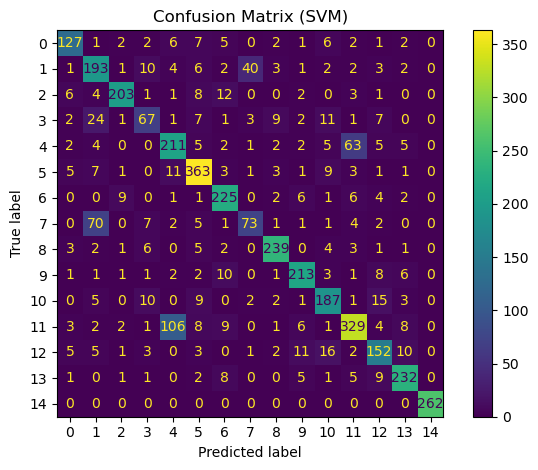

In [37]:
cm_SVM = confusion_matrix(y_test_SVM, y_pred_SVM)

labels = np.unique(y_test_SVM)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_SVM, display_labels=labels)
disp.plot(cmap="viridis", values_format=".2f" if cm_SVM.dtype.kind == "f" else "d")
plt.title("Confusion Matrix (SVM)")
plt.tight_layout()
plt.show()

### Closer look at data

Top mispredictions (true -> pred, count):
11 -> 4: 106
7 -> 1: 70
4 -> 11: 63
1 -> 7: 40
3 -> 1: 24
Showing 5/106 examples for true 11 → pred 4


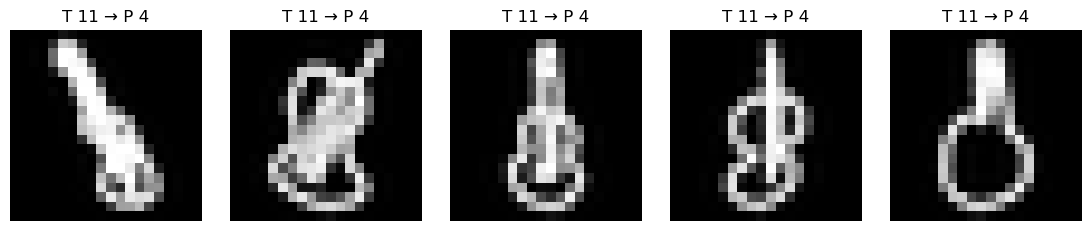

Showing 5/70 examples for true 7 → pred 1


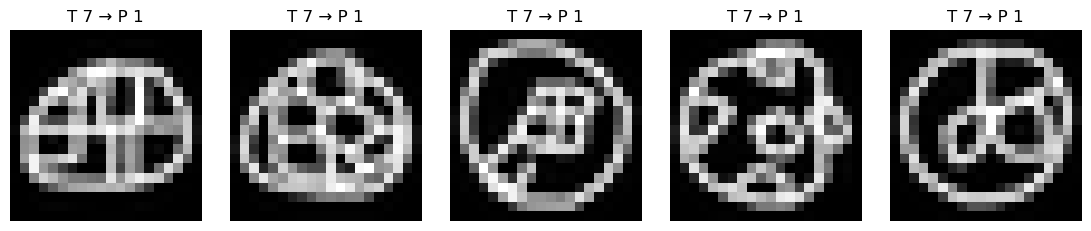

Showing 5/63 examples for true 4 → pred 11


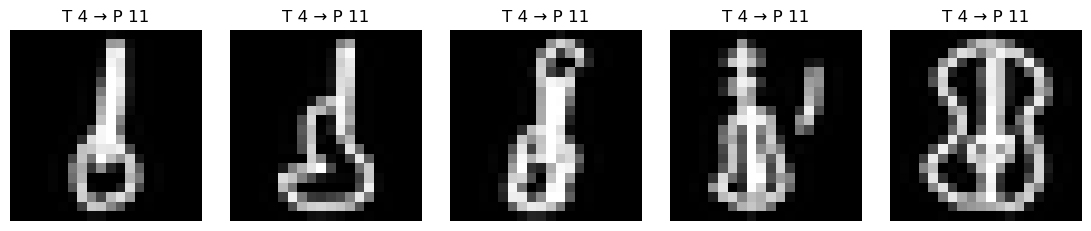

In [40]:

pairs = []
for t in range(cm_SVM.shape[0]):
    for p in range(cm_SVM.shape[1]):
        if t != p and cm_SVM[t, p] > 0:
            pairs.append((t, p, cm_SVM[t, p]))
pairs.sort(key=lambda x: x[2], reverse=True)  

print("Top mispredictions (true -> pred, count):")
for t, p, c in pairs[:5]:
    print(f"{t} -> {p}: {c}")



def show_pair_examples(X, y_true, y_pred, true_label, pred_label, k=5, shape=(20,20)):
    idx = np.where((y_true == true_label) & (y_pred == pred_label))[0]
    k = min(k, len(idx))
    print(f"Showing {k}/{len(idx)} examples for true {true_label} → pred {pred_label}")
    if k == 0:
        return
    sel = idx[:k]
    fig, axes = plt.subplots(1, k, figsize=(2.2*k, 2.2), constrained_layout=True)
    if k == 1: axes = [axes]
    for ax, i in zip(axes, sel):
        ax.imshow(X[i].reshape(*shape), cmap="gray")
        ax.set_title(f"T {y_true[i]} → P {y_pred[i]}")
        ax.axis("off")
    plt.show()


TOP_N = 3
K_PER_PAIR = 5
for t, p, _ in pairs[:TOP_N]:
    show_pair_examples(X_test_SVM, y_test_SVM, y_pred_SVM, true_label=t, pred_label=p, k=K_PER_PAIR)



## Classifier nr2: K-Nearest Neighbors

New splits to seperate data

In [41]:
X_train_K, X_test_K, y_train_K, y_test_K = train_test_split(X, y, test_size=0.30, random_state=seed)


print(f"Training data: {len(X_train_K)} rows.")
print(f"Testing (unseen) data: {len(X_test_K)} rows.")

Training data: 9146 rows.
Testing (unseen) data: 3921 rows.


Tune amount of neigbors and find the best k

In [ ]:
ks = list(range(1, 101))  
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
combos = [
    ("uniform", 1),  
    ("uniform", 2),  
    ("distance", 1), 
    ("distance", 2), 
]


pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

curves = {}  

for weights, p in combos:
    scores_curve = []
    for k in ks:
        pipe.set_params(knn__n_neighbors=k, knn__weights=weights, knn__p=p)
        scores = cross_val_score(
            pipe, X_train_K, y_train_K,
            cv=cv, scoring="f1_macro", n_jobs=-1
        )
        scores_curve.append(scores.mean())
    curves[(weights, p)] = scores_curve
    
    best_idx = int(np.argmax(scores_curve))
    print(f"weights={weights:8s}, p={p} -> best k={ks[best_idx]}, CV Macro-F1={scores_curve[best_idx]:.3f}")



weights=uniform , p=1 -> best k=4, CV Macro-F1=0.688
weights=uniform , p=2 -> best k=5, CV Macro-F1=0.705
weights=distance, p=1 -> best k=4, CV Macro-F1=0.700
weights=distance, p=2 -> best k=6, CV Macro-F1=0.711


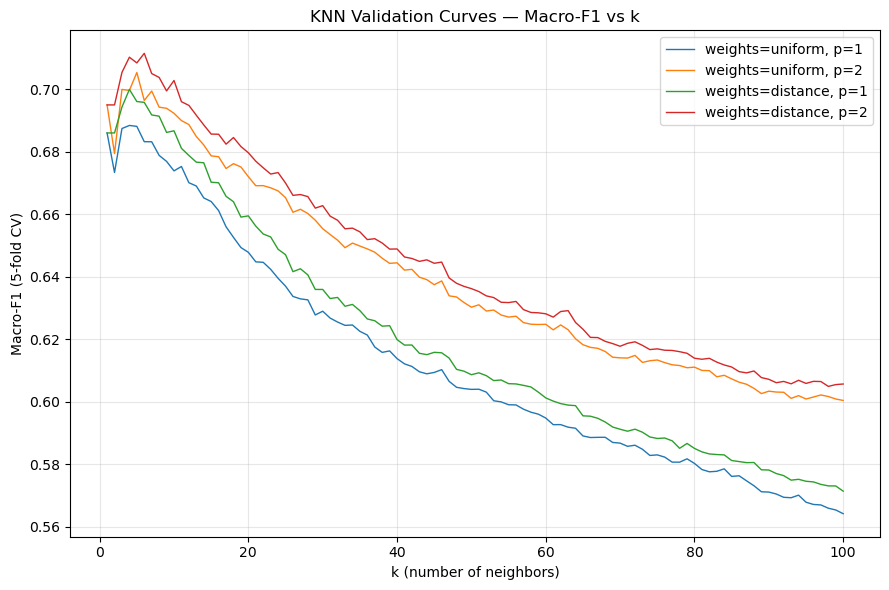

,Weights,p (Distance Metric),Best k,CV Macro-F1
0,uniform,1,4,0.688
1,uniform,2,5,0.705
2,distance,1,4,0.700
3,distance,2,6,0.711


In [43]:

plt.figure(figsize=(9, 6))
for (weights, p), vals in curves.items():
    label = f"weights={weights}, p={p}"
    plt.plot(ks, vals, label=label, linewidth=1)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Macro-F1 (5-fold CV)")
plt.title("KNN Validation Curves — Macro-F1 vs k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


data = [
    ["uniform", 1, 4, 0.688],
    ["uniform", 2, 5, 0.705],
    ["distance", 1, 4, 0.700],
    ["distance", 2, 6, 0.711]
]

df = pd.DataFrame(data, columns=["Weights", "p (Distance Metric)", "Best k", "CV Macro-F1"])
display(df)

## Final fit of K_NN

Test Macro-F1 : 0.7123
              precision    recall  f1-score   support

           0      0.671     0.858     0.753       162
           1      0.479     0.715     0.574       242
           2      0.762     0.870     0.812       246
           3      0.661     0.256     0.369       160
           4      0.609     0.582     0.595       311
           5      0.932     0.750     0.831       420
           6      0.868     0.789     0.827       266
           7      0.544     0.214     0.307       173
           8      0.764     0.884     0.819       249
           9      0.861     0.850     0.855       247
          10      0.774     0.767     0.770       236
          11      0.695     0.725     0.710       491
          12      0.657     0.641     0.649       206
          13      0.720     0.929     0.812       255
          14      1.000     1.000     1.000       257

    accuracy                          0.740      3921
   macro avg      0.733     0.722     0.712      3921
wei

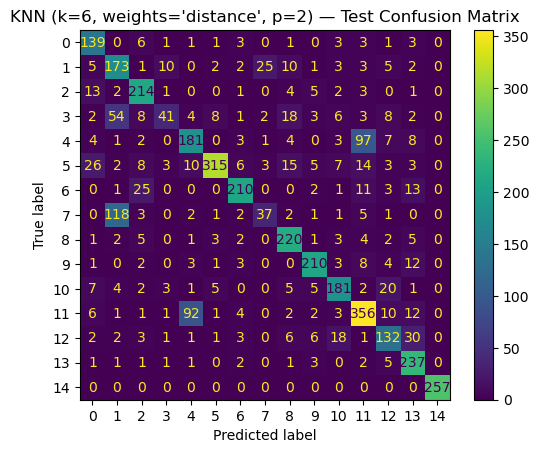

In [54]:
best_k = 6
best_weight = "distance" 
best_p= 2

pipe_final_K = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=best_k,
        weights=best_weight,
        p=best_p,
        n_jobs=-1
    ))
])

pipe_final_K.fit(X_train_K, y_train_K)

y_pred_K = pipe_final_K.predict(X_test_K)

macro_f1_KNN = f1_score(y_test_K, y_pred_K, average="macro")

print(f"Test Macro-F1 : {macro_f1_KNN:.4f}")
print(classification_report(y_test_K, y_pred_K, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test_K, y_pred_K, cmap="viridis")
plt.title(f"KNN (k={best_k}, weights='{best_weight}', p={best_p}) — Test Confusion Matrix")
plt.show()



Confusion matrix for final K_NN fit

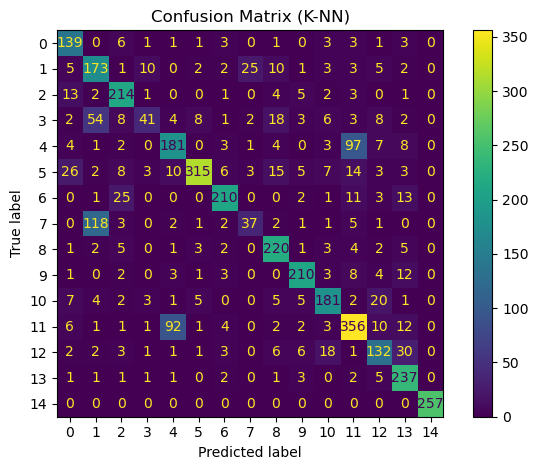

In [45]:
cm_K = confusion_matrix(y_test_K, y_pred_K)

labels = np.unique(y_test_K)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_K, display_labels=labels)
disp.plot(cmap="viridis", values_format=".2f" if cm_K.dtype.kind == "f" else "d")
plt.title("Confusion Matrix (K-NN)")
plt.tight_layout()
plt.show()

Top mispredictions (true -> pred, count):
7 -> 1: 118
4 -> 11: 97
11 -> 4: 92
3 -> 1: 54
12 -> 13: 30
Showing 5/118 examples for true 7 → pred 1


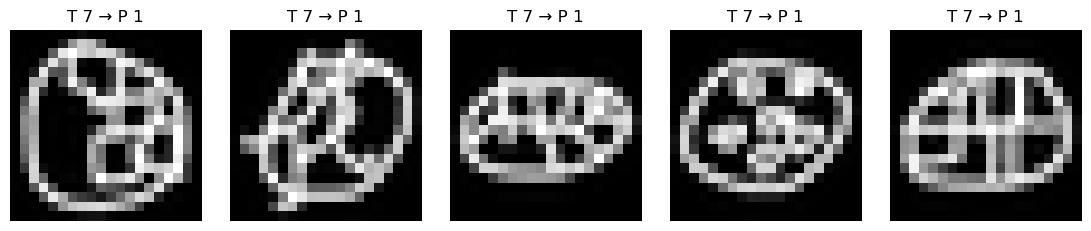

Showing 5/97 examples for true 4 → pred 11


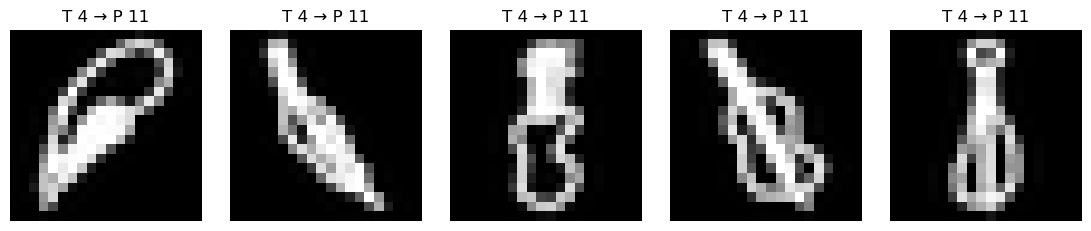

Showing 5/92 examples for true 11 → pred 4


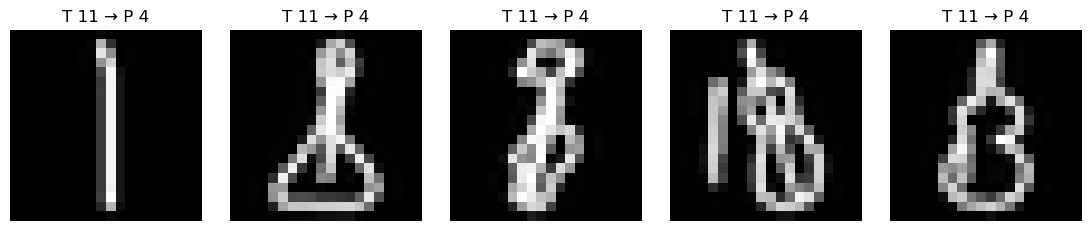

In [46]:
pairs = []
for t in range(cm_K.shape[0]):
    for p in range(cm_K.shape[1]):
        if t != p and cm_K[t, p] > 0:
            pairs.append((t, p, cm_K[t, p]))
pairs.sort(key=lambda x: x[2], reverse=True)  

print("Top mispredictions (true -> pred, count):")
for t, p, c in pairs[:5]:
    print(f"{t} -> {p}: {c}")



def show_pair_examples(X, y_true, y_pred, true_label, pred_label, k=5, shape=(20,20)):
    idx = np.where((y_true == true_label) & (y_pred == pred_label))[0]
    k = min(k, len(idx))
    print(f"Showing {k}/{len(idx)} examples for true {true_label} → pred {pred_label}")
    if k == 0:
        return
    sel = idx[:k]
    fig, axes = plt.subplots(1, k, figsize=(2.2*k, 2.2), constrained_layout=True)
    if k == 1: axes = [axes]
    for ax, i in zip(axes, sel):
        ax.imshow(X[i].reshape(*shape), cmap="gray")
        ax.set_title(f"T {y_true[i]} → P {y_pred[i]}")
        ax.axis("off")
    plt.show()


TOP_N = 3
K_PER_PAIR = 5
for t, p, _ in pairs[:TOP_N]:
    show_pair_examples(X_test_K, y_test_K, y_pred_K, true_label=t, pred_label=p, k=K_PER_PAIR)


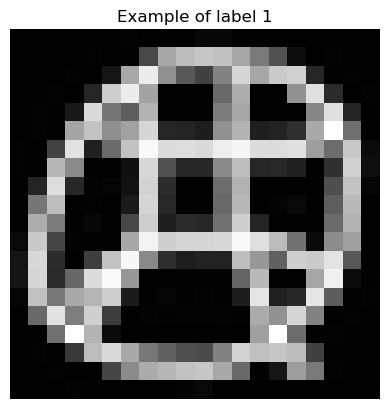

In [47]:
label = 1
idx = np.where(y == label)[0]         
i = np.random.choice(idx)  

plt.imshow(X[i].reshape(20, 20), cmap="gray")   
plt.title(f"Example of label {label}")
plt.axis("off")
plt.show()

# TASK 2

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best PCA setting: {'pca__n_components': 57}
Best CV Macro-F1: 0.7897


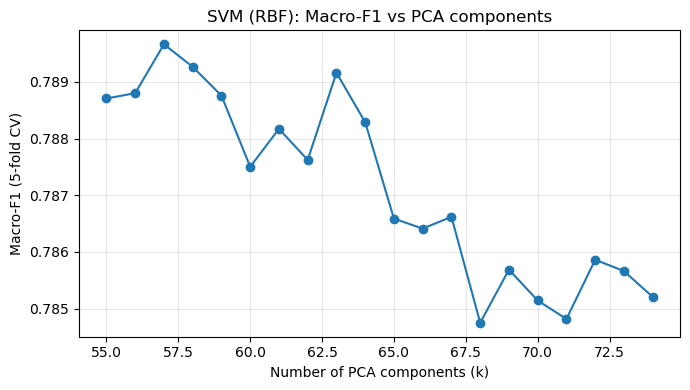

In [ ]:
from sklearn.decomposition import PCA
import time


best_C = 5
best_gamma = "scale"


pipe_pca_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=seed)),
    ("clf", SVC(kernel="rbf", C=best_C, gamma=best_gamma, class_weight="balanced", random_state=seed))
])

components_wide= [25, 50, 75, 100, 125, 150, 200, 250, 300] #wide range, was used first
components_narrow = range(55,75) # small range

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
param_grid = {"pca__n_components": components_narrow}


param_grid = {"pca__n_components": components_narrow}
gs_SVM_PCA= GridSearchCV(
    estimator=pipe_pca_svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

gs_SVM_PCA.fit(X_train_SVM, y_train_SVM)


print("\nBest PCA setting:", gs_SVM_PCA.best_params_)
print(f"Best CV Macro-F1: {gs_SVM_PCA.best_score_:.4f}")


res = gs_SVM_PCA.cv_results_
k_vals = [int(v) for v in res["param_pca__n_components"]]
mean_scores = res["mean_test_score"]

plt.figure(figsize=(7,4))
plt.plot(k_vals, mean_scores, marker="o")
plt.xlabel("Number of PCA components (k)")
plt.ylabel("Macro-F1 (5-fold CV)")
plt.title("SVM (RBF): Macro-F1 vs PCA components")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Test Macro-F1 (PCA=57): 0.7875533272992719
              precision    recall  f1-score   support

           0      0.817     0.817     0.817       164
           1      0.631     0.685     0.657       270
           2      0.904     0.855     0.878       241
           3      0.601     0.610     0.606       136
           4      0.627     0.730     0.675       307
           5      0.842     0.902     0.871       409
           6      0.828     0.883     0.855       257
           7      0.606     0.515     0.557       167
           8      0.885     0.895     0.890       267
           9      0.853     0.860     0.857       250
          10      0.827     0.813     0.820       235
          11      0.806     0.675     0.735       480
          12      0.746     0.725     0.736       211
          13      0.860     0.860     0.860       265
          14      1.000     1.000     1.000       262

    accuracy                          0.797      3921
   macro avg      0.789     0.788    

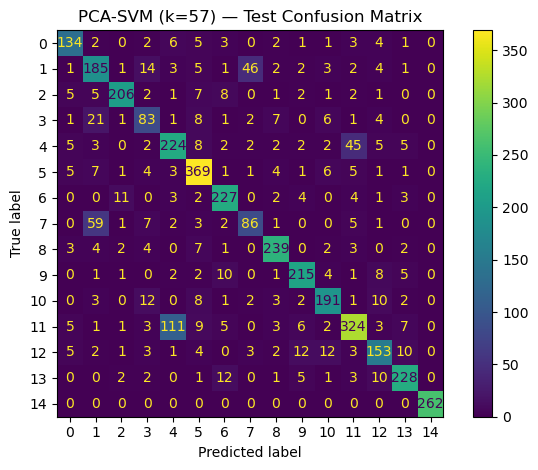

57


In [ ]:
best_c = 5
best_k = 57
best_gamma = "scale"

final_pca_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_k, random_state=seed)),
    ("clf", SVC(kernel="rbf", C=best_C, gamma=best_gamma, class_weight="balanced", random_state=seed))
])

final_pca_svm.fit(X_train_SVM, y_train_SVM)

y_pred_pca = final_pca_svm.predict(X_test_SVM)

macro_f1 = f1_score(y_test_SVM, y_pred_pca, average="macro")
print(f"Test Macro-F1 (PCA={best_k}): {macro_f1}")
print(classification_report(y_test_SVM, y_pred_pca, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test_SVM, y_pred_pca, cmap="viridis")
plt.title(f"PCA-SVM (k={best_k}) — Test Confusion Matrix")
plt.tight_layout()
plt.show()



timetaking


In [ ]:
#full dataset

final_svm_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf",
                C=5,
                gamma="scale",
                class_weight="balanced",
                random_state=seed))
])



start_train_full = time.time()
final_svm_full.fit(X_train_SVM, y_train_SVM)
train_time_full = time.time() - start_train_full

start_pred_full = time.time()
y_pred_full = final_svm_full.predict(X_test_SVM)
pred_time_full = time.time() - start_pred_full

macro_f1_full = f1_score(y_test_SVM, y_pred_full, average="macro")

print(f"Test Macro-F1 : {macro_f1_full:.4f}")
print(f"Training time: {train_time_full:.2f}s")
print(f"Prediction time: {pred_time_full:.2f}s")
print(f"Total runtime: {train_time_full + pred_time_full}")

print(classification_report(y_test_SVM, y_pred_full, digits=3))





57
Test Macro-F1 : 0.7704
Training time: 6.46s
Prediction time: 4.58s
Total runtime: 11.034637928009033
              precision    recall  f1-score   support

           0      0.814     0.774     0.794       164
           1      0.607     0.715     0.656       270
           2      0.910     0.842     0.875       241
           3      0.615     0.493     0.547       136
           4      0.612     0.687     0.647       307
           5      0.842     0.888     0.864       409
           6      0.804     0.875     0.838       257
           7      0.603     0.437     0.507       167
           8      0.895     0.895     0.895       267
           9      0.845     0.852     0.849       250
          10      0.757     0.796     0.776       235
          11      0.774     0.685     0.727       480
          12      0.714     0.720     0.717       211
          13      0.853     0.875     0.864       265
          14      1.000     1.000     1.000       262

    accuracy                  

Confusion matrix for full dataset, with final svm classifier

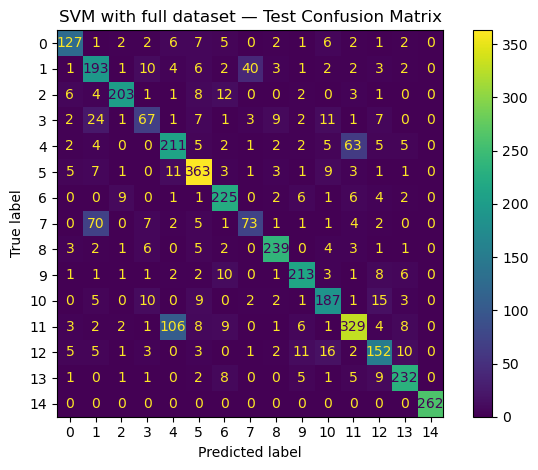

57


In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_SVM, y_pred_full, cmap="viridis")
plt.title(f"SVM with full dataset — Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
#reduced dataset


final_svm_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_k, random_state=seed)),
    ("clf", SVC(kernel="rbf",
                C=5,
                gamma="scale",
                class_weight="balanced",
                random_state=seed))
])

start_train_pca = time.time()
final_svm_pca.fit(X_train_SVM, y_train_SVM)
train_time_pca = time.time() - start_train_pca

start_pred_pca = time.time()
y_pred_pca = final_pca_svm.predict(X_test_SVM)
pred_time_pca = time.time() - start_pred_pca

macro_f1_pca = f1_score(y_test_SVM, y_pred_pca, average="macro")

print(f"Test Macro-F1 (PCA={best_k}): {macro_f1_pca:.4f}")
print(f"Training time: {train_time_pca:.2f}s")
print(f"Prediction time: {pred_time_pca:.2f}s")
print(f"Total runtime: {train_time_pca + pred_time_pca}")

print(classification_report(y_test_SVM, y_pred_pca, digits=3))




57
Test Macro-F1 (PCA=57): 0.7876
Training time: 2.16s
Prediction time: 2.44s
Total runtime: 4.601332187652588
              precision    recall  f1-score   support

           0      0.817     0.817     0.817       164
           1      0.631     0.685     0.657       270
           2      0.904     0.855     0.878       241
           3      0.601     0.610     0.606       136
           4      0.627     0.730     0.675       307
           5      0.842     0.902     0.871       409
           6      0.828     0.883     0.855       257
           7      0.606     0.515     0.557       167
           8      0.885     0.895     0.890       267
           9      0.853     0.860     0.857       250
          10      0.827     0.813     0.820       235
          11      0.806     0.675     0.735       480
          12      0.746     0.725     0.736       211
          13      0.860     0.860     0.860       265
          14      1.000     1.000     1.000       262

    accuracy           

Comparison

In [69]:
rows = [
    ["SVM (Full 400)", f"{train_time_full:.3f}", f"{pred_time_full:.3f}", f"{(train_time_full+pred_time_full):.3f}", f"{macro_f1_full:.4f}"],
    [f"SVM + PCA (k={best_k})", f"{train_time_pca:.3f}", f"{pred_time_pca:.3f}", f"{(train_time_pca+pred_time_pca):.3f}", f"{macro_f1_pca:.4f}"],
]

df = pd.DataFrame(rows, columns=["Model", "Train time (s)", "Test time (s)", "Total time (s)", "Macro-F1"])
display(df)



,Model,Train time (s),Test time (s),Total time (s),Macro-F1
0,SVM (Full 400),6.459,4.576,11.035,0.7704
1,SVM + PCA (k=57),2.158,2.443,4.601,0.7876


In [61]:


pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=57, random_state=seed)),
    ("clf", SVC(kernel="rbf", class_weight="balanced", random_state=seed))
])

param_grid = {
    "clf__C": [1, 3, 5, 10],
    "clf__gamma": ["scale", 0.01, 0.003, 0.001]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

gs_k57 = GridSearchCV(pipe, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True, verbose=0)
gs_k57.fit(X_train_SVM, y_train_SVM)

print("Best params (k=57):", gs_k57.best_params_)
print("Best CV Macro-F1:", gs_k57.best_score_)
y_pred_k57 = gs_k57.best_estimator_.predict(X_test_SVM)
print("Test Macro-F1 (retuned, k=57):", f1_score(y_test_SVM, y_pred_k57, average="macro"))

Best params (k=57): {'clf__C': 5, 'clf__gamma': 'scale'}
Best CV Macro-F1: 0.7896650178614392
Test Macro-F1 (retuned, k=57): 0.7875533272992719


# TASK 3

(405, 400)


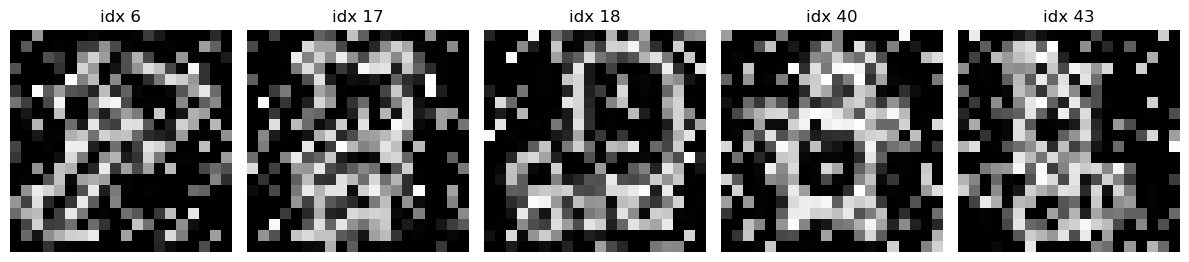

In [ ]:
datasetCorrupt = np.load("dataset_corrupted.npz")
X_corrupt= datasetCorrupt["X"]
print(X_corrupt.shape)

X_img = X_corrupt.reshape(-1, 20, 20)




corrupted = [6, 17, 18, 40, 43]   

imgs = X_corrupt[corrupted].reshape(-1, 20, 20)

fig, axes = plt.subplots(1, len(corrupted), figsize=(2.4*len(corrupted), 2.6))
for ax, img, idx in zip(axes, imgs, corrupted):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"idx {idx}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


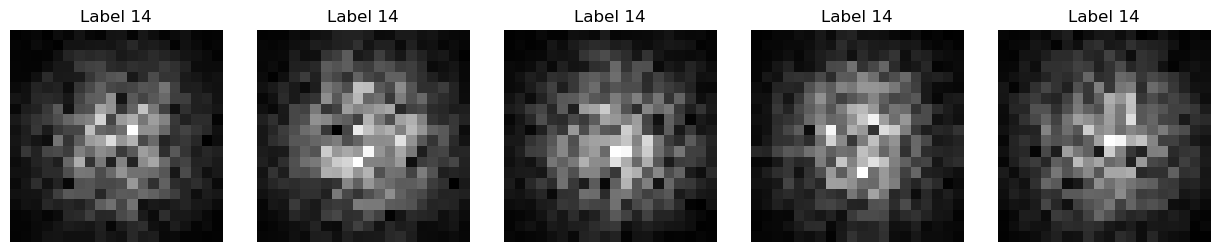

In [ ]:

data = np.load("dataset.npz")
X, y = data["X"], data["y"]


mask = (y == 14)
X_label14 = X[mask]


X_label14_img = X_label14.reshape(-1, 20, 20)


k = min(5, len(X_label14_img))


fig, axes = plt.subplots(1, k, figsize=(2.5*k, 2.5))
for ax, img in zip(axes, X_label14_img[:k]):
    ax.imshow(img, cmap="gray")
    ax.set_title("Label 14")
    ax.axis("off")

plt.tight_layout()
plt.show()

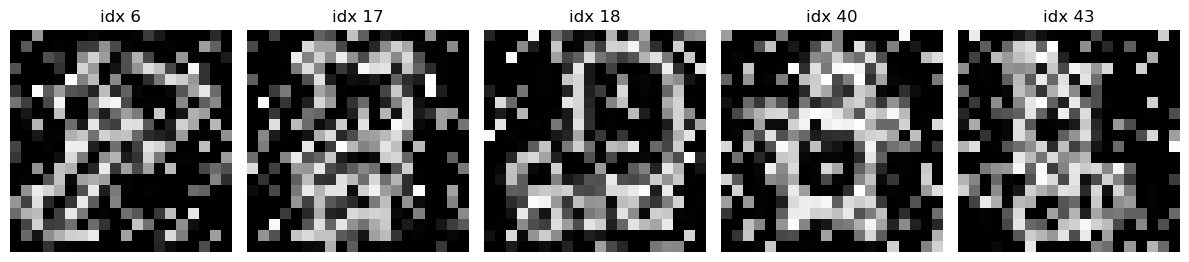

In [ ]:

corrupted = [6, 17, 18, 40, 43]  

imgs = X_corrupt[corrupted].reshape(-1, 20, 20)

fig, axes = plt.subplots(1, len(corrupted), figsize=(2.4*len(corrupted), 2.6))
for ax, img, idx in zip(axes, imgs, corrupted):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"idx {idx}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


Found 16 images predicted as label 14.


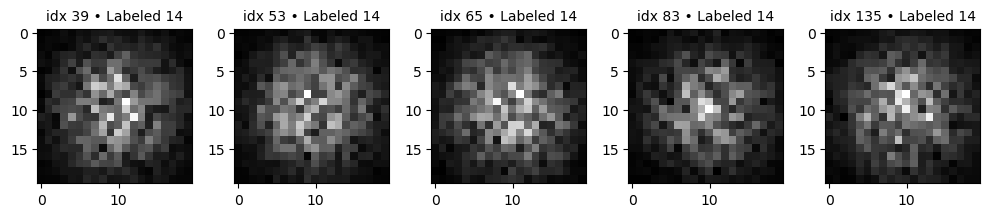

In [145]:
y_pred_corrupt = final_pca_svm.predict(X_corrupt)  
idx_14 = np.where(y_pred_corrupt == 14)[0]

print(f"Found {len(idx_14)} images predicted as label 14.")

k = min(25, len(idx_14))
sel = idx_14[:k]
imgs = X_corrupt[sel].reshape(-1, 20, 20)


rows = 1
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
axes = axes.ravel()




for ax, img, idx in zip(axes[:k], imgs, sel):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"idx {idx} • Labeled 14", fontsize=10)

plt.tight_layout()
plt.show()

margin based

In [ ]:



S_new = final_pca_svm.decision_function(X_corrupt) 


part_new = np.partition(S_new, -2, axis=1)[:, -2:]
new_max1 = np.max(part_new, axis=1)
new_max2 = np.min(part_new, axis=1)
margins_new = new_max1 - new_max2 



Margin for wanted index

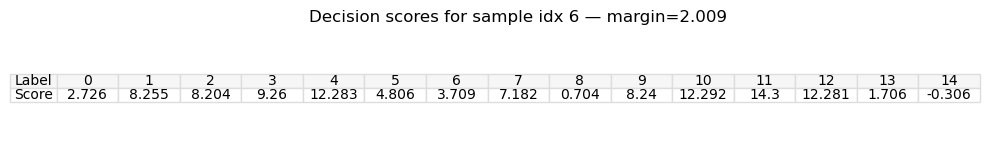

In [ ]:
i = 6


scores = final_pca_svm.decision_function(X_corrupt[i].reshape(1, -1))[0]


try:
    margin = float(margins_new[i])
except NameError:
    top2 = np.partition(scores, -2)[-2:]
    margin = float(top2.max() - top2.min())

labels = np.arange(len(scores))
scores_rounded = np.round(scores, 3)

fig, ax = plt.subplots(figsize=(10, 1.6))
ax.axis("off")

table_data = [labels, scores_rounded]
row_labels = ["Label", "Score"]

tbl = ax.table(cellText=table_data,
               rowLabels=row_labels,
               cellLoc="center", rowLoc="center",
               loc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)


for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#DDDDDD")
    if row == 0:
        cell.set_facecolor("#F6F6F6")

plt.title(f"Decision scores for sample idx {i} — margin={margin:.3f}", pad=10)
plt.tight_layout()
plt.show()

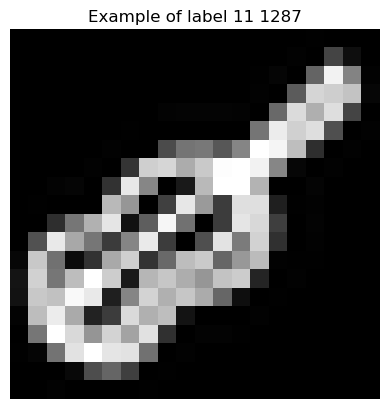

In [214]:
     
i = 1287 # index of violin
plt.imshow(X[i].reshape(20, 20), cmap="gray")   
plt.title(f"Example of label {label} {i}")
plt.axis("off")
plt.show()

In [221]:
final_svm_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_k, random_state=seed)),
    ("clf", SVC(kernel="rbf",
                C=5,
                gamma="scale",
                class_weight="balanced",
                random_state=seed))
])

y_pred_disrupted = final_pca_svm.predict(X_corrupt)




Antall bilder predikert som 11: 120


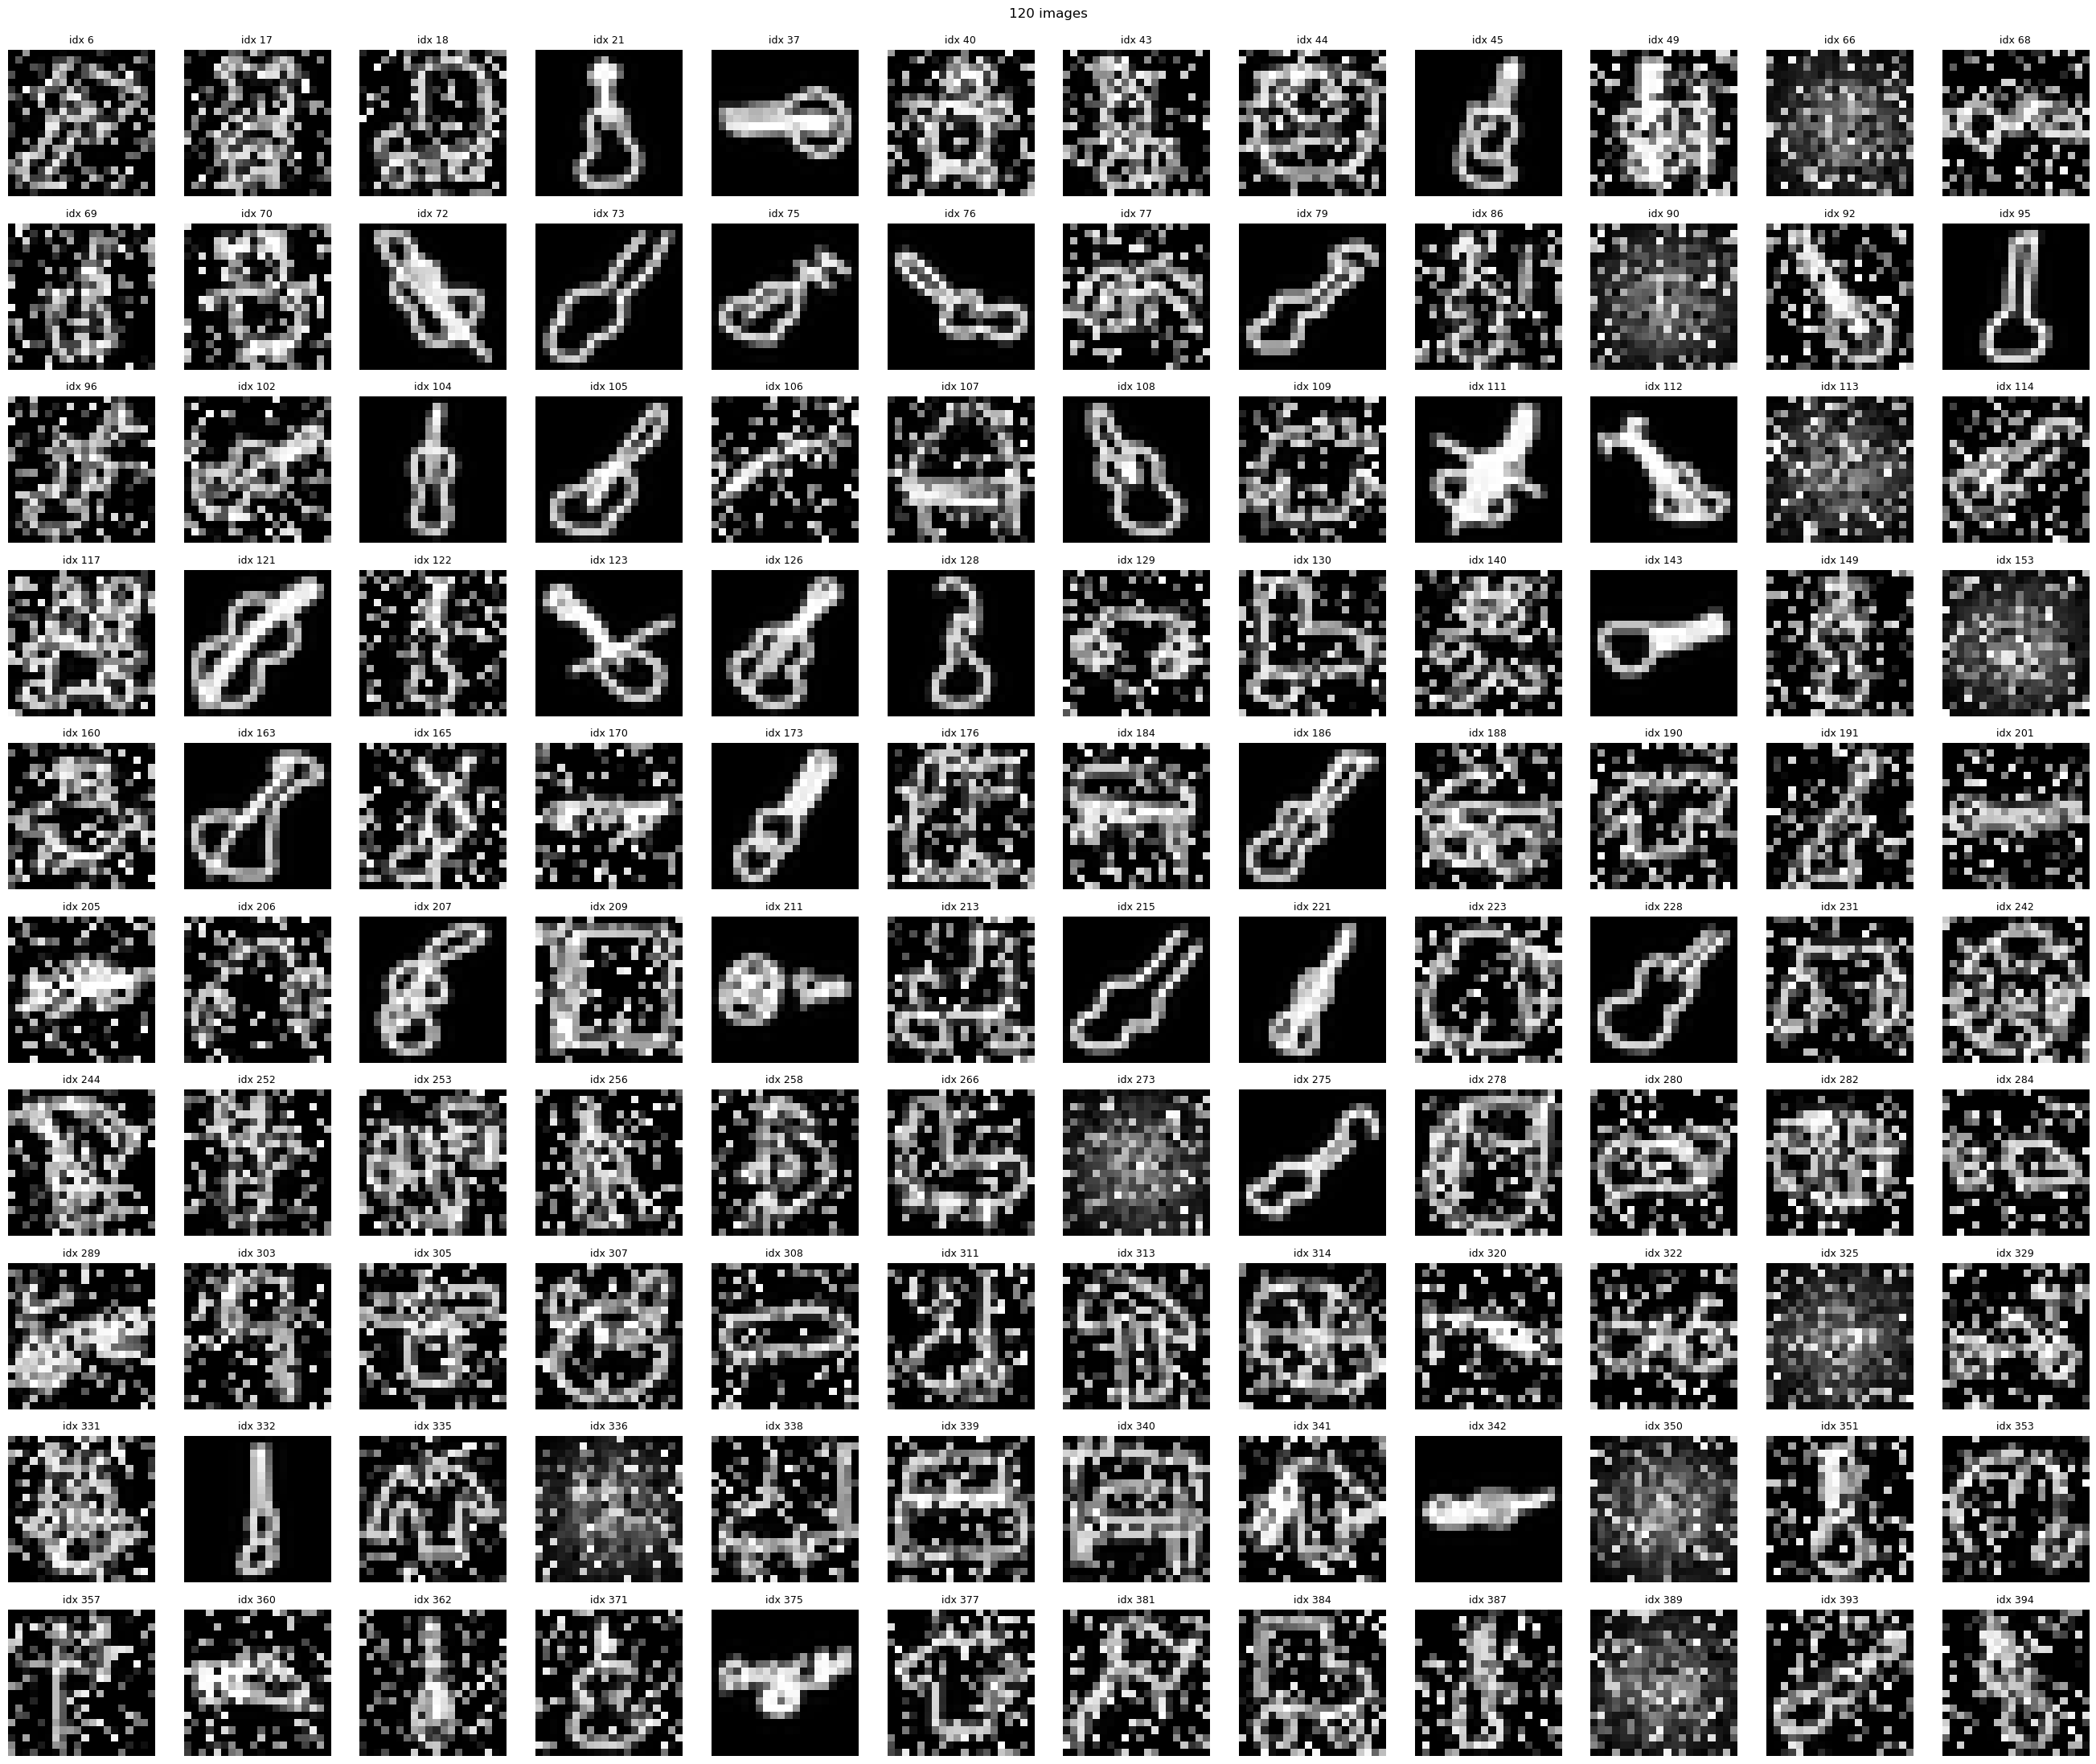

In [226]:

idx_11 = np.where(y_pred_disrupted == 11)[0]
print(f"Antall bilder predikert som 11: {len(idx_11)}")



imgs = X_corrupt[idx_11].reshape(-1, 20, 20)
k = len(imgs)
cols = 12
rows = 10


fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
axes = np.atleast_1d(axes).ravel()

for ax, img, idx in zip(axes[:k], imgs, idx_11):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"idx {idx}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"{k} images", y=0.995)
plt.tight_layout()
plt.show()

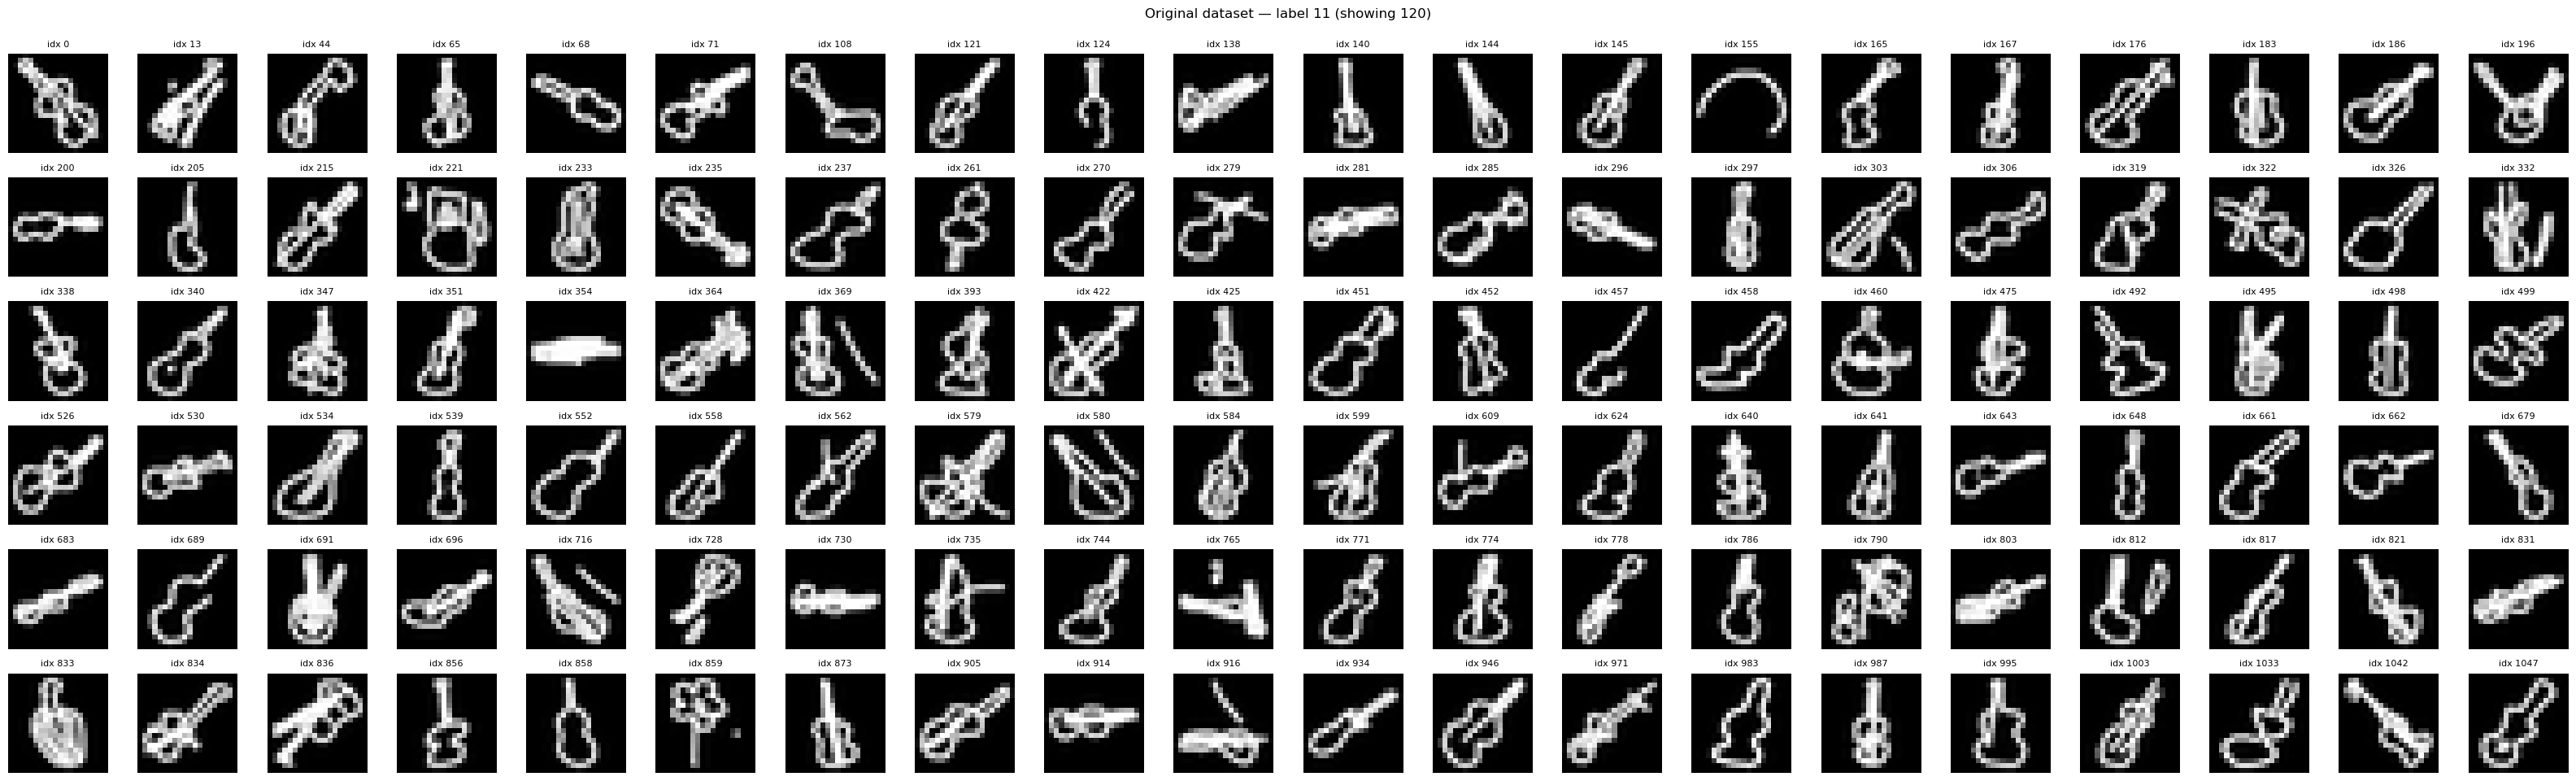

In [234]:

idx_11 = np.where(y == 11)[0]


k = min(120, len(idx_11))
sel = idx_11[:k] 

imgs = X[sel].reshape(-1, 20, 20)


rows, cols = 6, 20

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.6, rows*1.6))
axes = np.atleast_1d(axes).ravel()

for ax, img, idx in zip(axes[:k], imgs, sel):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"idx {idx}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Original dataset — label 11 (showing {k})", y=0.995, fontsize=12)
plt.tight_layout()
plt.show()

Indices to be checked manually

In [ ]:
idx_pred_11 = np.where(y_pred_corrupt == 11)[0]

k = min(120, len(idx_pred_11))
mat = np.full((6, 20), fill_value=-1, dtype=int)  
mat.flat[:k] = idx_pred_11[:k]


print("Indices predicted as label 11 (6x20 grid):\n")
for row in mat:
    print(" ".join(f"{i:4d}" if i >= 0 else "    " for i in row))

Indices predicted as label 11 (6x20 grid):

   6   17   18   21   37   40   43   44   45   49   66   68   69   70   72   73   75   76   77   79
  86   90   92   95   96  102  104  105  106  107  108  109  111  112  113  114  117  121  122  123
 126  128  129  130  140  143  149  153  160  163  165  170  173  176  184  186  188  190  191  201
 205  206  207  209  211  213  215  221  223  228  231  242  244  252  253  256  258  266  273  275
 278  280  282  284  289  303  305  307  308  311  313  314  320  322  325  329  331  332  335  336
 338  339  340  341  342  350  351  353  357  360  362  371  375  377  381  384  387  389  393  394
